In [1]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

In [13]:
from pyqit.data.datamodule import DataModule

dm = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
    backend="pennylane",
)

In [14]:
from pyqit.ansatzes.sel import SELAnsatz
from pyqit.core.embeddings import AngleEmbedding
from pyqit.core.trainer import Trainer
from pyqit.models.vqc import VQCClassifier

# Initialize the VQC
model = VQCClassifier(
    n_qubits=4,
    n_layers=3,
    n_classes=2,
    ansatz=SELAnsatz,
    encoder=AngleEmbedding,
    backend="pennylane",
)

# Spin up the Trainer
trainer = Trainer(backend_type="pennylane", max_epochs=15, learning_rate=0.05)

history = trainer.fit(model, datamodule=dm)

 Parameter             Value          
 Model Name            VQCClassifier  
 Backend               Pennylane      
 Qubits                4              
 Ansatz                SELAnsatz      
 Encoder               AngleEmbedding 
 Optimizer             ADAM           
 Learning Rate         0.05           
 Train / Val Samples   140 / 30       

Output()

[Trainer] Training complete.

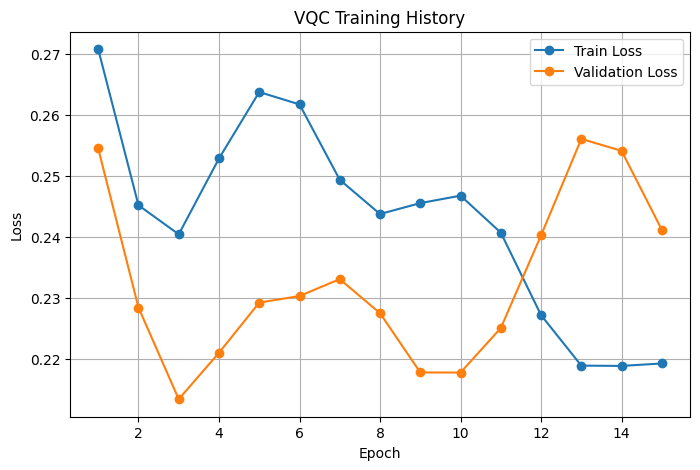

In [15]:
import matplotlib.pyplot as plt

# Extract metrics from the history
train_loss = history.as_dict()["train_loss"]
val_loss = history.as_dict()["val_loss"]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, val_loss, label="Validation Loss", marker="o")
plt.title("VQC Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Standalone VQC Test Accuracy: 63.33%


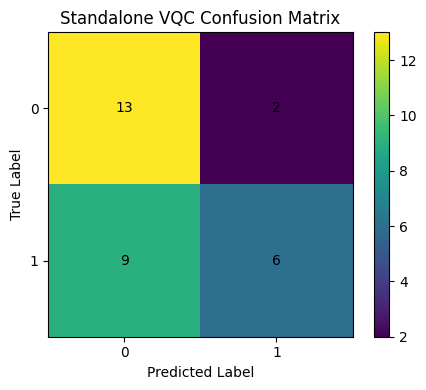

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on the holdout Test Set
predictions = trainer.predict(model, datamodule=dm, return_format="numpy")
actuals = dm.y_test.astype(int)

# Calculate Accuracy
acc = accuracy_score(actuals, predictions)
print(f"Standalone VQC Test Accuracy: {acc * 100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Standalone VQC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks(np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()

# Using `QuantumPipeline`

In [7]:
dm_new = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
    backend="torch",
)

In [16]:
from pyqit.core.pipeline import PipelineStage, QuantumPipeline

# Stage 1: The "Pre-trained" Backbone (Frozen)
backbone = VQCClassifier(n_qubits=4, n_layers=4, n_classes=4, backend="torch")
stage_1 = PipelineStage(backbone, name="feature_extractor", trainable=False)

# Stage 2: The Trainable Head
head = VQCClassifier(n_qubits=4, n_layers=1, backend="torch")
stage_2 = PipelineStage(head, name="classifier", trainable=True)

# Combine them into a Pipeline
pipeline = QuantumPipeline([stage_1, stage_2], mode="sequential")
trainer_new = Trainer(backend_type="torch", max_epochs=40, learning_rate=0.2)

print("\nTraining Quantum Pipeline...")
pipeline.fit(datamodule=dm_new, trainers=trainer_new, fit_mode="frozen_backbone")


Training Quantum Pipeline...


 Parameter             Value          
 Model Name            VQCClassifier  
 Backend               Torch          
 Qubits                4              
 Ansatz                SELAnsatz      
 Encoder               AngleEmbedding 
 Optimizer             ADAM           
 Learning Rate         0.2            
 Train / Val Samples   140 / 30       

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
└───┴──────┴──────┴────────┴──────┴───────┘

Trainable params: 0                                                                                                
Non-trainable params: 0                                                                                            
Total params: 0                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains 
tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. 
Consider replacing Autograd with vanilla NumPy.
  warnings.warn(

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=40` reached.


QuantumPipeline(mode=sequential)
  ('feature_extractor', Stage(feature_extractor [frozen]))
  ('classifier', Stage(classifier))

Pipeline Test Accuracy: 60.00%


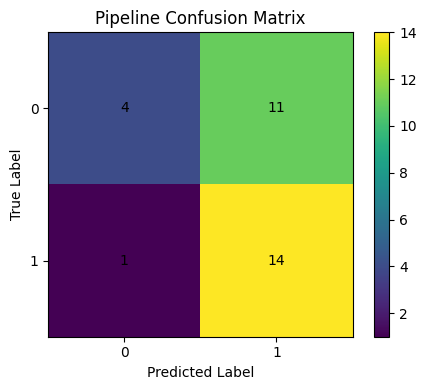

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

pipeline_preds = pipeline.predict(
    X=dm_new.X_test, batch_size=16, backend="torch", return_format="numpy"
)
actuals = dm_new.y_test

pipe_acc = accuracy_score(actuals, pipeline_preds)
print(f"Pipeline Test Accuracy: {pipe_acc * 100:.2f}%")

pipe_cm = confusion_matrix(actuals, pipeline_preds)

plt.figure(figsize=(5, 4))
plt.imshow(pipe_cm)
plt.title("Pipeline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(pipe_cm.shape[0]):
    for j in range(pipe_cm.shape[1]):
        plt.text(j, i, pipe_cm[i, j], ha="center", va="center")

plt.xticks(np.arange(pipe_cm.shape[1]))
plt.yticks(np.arange(pipe_cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()